# Week 10: Machine Learning  models
## Logistic regression, KNN, SVM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('data10_FraudDetection_creditcard.csv')
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [4]:
df.Class.value_counts()

Class
0    99776
1      223
Name: count, dtype: int64

In [5]:
y = df['Class']
x = df.loc[:, df.columns != 'Class']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=101)
y_test.sample(4)

45185    0
28494    0
99448    0
85911    0
Name: Class, dtype: int64

In [6]:
lr = LogisticRegression(penalty='l2', C=100, max_iter=1000)
lr.fit(x_train,y_train)

/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=100, max_iter=1000)

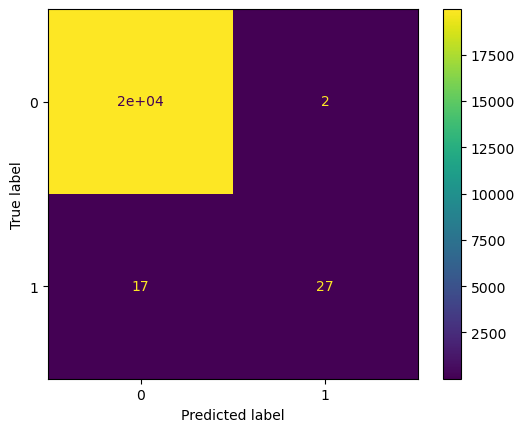

In [7]:
ConfusionMatrixDisplay.from_estimator(lr, x_test, y_test)

In [8]:
y_pred = lr.predict(x_test)

acscore = accuracy_score(y_test, y_pred)
print(f'Accuracy Score = {acscore}')

print('Classification Report:')
print(classification_report(y_test,y_pred))

Accuracy Score = 0.99905
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19956
           1       0.93      0.61      0.74        44

    accuracy                           1.00     20000
   macro avg       0.97      0.81      0.87     20000
weighted avg       1.00      1.00      1.00     20000



In [12]:
knc = KNeighborsClassifier(n_neighbors=70)
knc.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=70)

In [13]:
#ConfusionMatrixDisplay.from_estimator(knc, x_test, y_test)
y_pred = knc.predict(x_test)

acscore = accuracy_score(y_test, y_pred)
print(f'Accuracy Score = {acscore}')

print('Classification Report:')
print(classification_report(y_test,y_pred))

AttributeError: 'Flags' object has no attribute 'c_contiguous'

In [16]:
svc = SVC(kernel='linear', C=10, random_state=101, class_weight='balance')
svc.fit(x_train, y_train)
ConfusionMatrixDisplay.from_estimator(svc, x_test, y_test)

NameError: name 'SVC' is not defined